# Analisi della produzione di energia nucleare nel mondo

**Obiettivo**: esplorare come si distribuisce la produzione di energia nucleare tra i paesi del mondo, come è cambiata nel tempo, e se esiste una relazione tra la ricchezza economica di un paese (PIL) e la sua quota di nucleare nel mix elettrico.

**Dataset**: [Our World in Data - Energy](https://github.com/owid/energy-data), dati globali su produzione e consumo energetico per paese, dal 1900 ad oggi.

**Periodo analizzato**: dal 1950 in poi (il nucleare civile nasce a metà anni '50).


In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../data/raw/owid-energy-data.csv") # importo i dati

In [3]:
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [4]:
df.shape

(23377, 130)

In [5]:
df.columns.tolist()


['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'biofuel_cons_change_pct',
 'biofuel_cons_change_twh',
 'biofuel_cons_per_capita',
 'biofuel_consumption',
 'biofuel_elec_per_capita',
 'biofuel_electricity',
 'biofuel_share_elec',
 'biofuel_share_energy',
 'carbon_intensity_elec',
 'coal_cons_change_pct',
 'coal_cons_change_twh',
 'coal_cons_per_capita',
 'coal_consumption',
 'coal_elec_per_capita',
 'coal_electricity',
 'coal_prod_change_pct',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'coal_share_elec',
 'coal_share_energy',
 'electricity_demand',
 'electricity_demand_per_capita',
 'electricity_generation',
 'electricity_share_energy',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'energy_per_capita',
 'energy_per_gdp',
 'fossil_cons_change_pct',
 'fossil_cons_change_twh',
 'fossil_elec_per_capita',
 'fossil_electricity',
 'fossil_energy_per_capita',
 'fossil_fuel_consumption',
 'fossil_share_elec',
 'fossil_share_energy',
 'gas_cons_chan

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), str(2)
memory usage: 23.2 MB


In [7]:
df.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,23377.000000,1.889400e+04,1.178000e+04,2070.000000,7903.000000,6338.000000,8057.000000,6015.000000,6337.000000,6311.000000,...,7869.000000,6379.000000,2798.000000,6293.000000,6405.000000,8405.000000,9507.000000,5145.000000,7661.000000,6379.000000
mean,1976.238611,1.058587e+08,4.257565e+11,43.478804,1.054261,55.157113,15.092054,70.470840,12.503951,1.961657,...,1.115394,0.219802,290.408294,6.021235,48.691257,70.093757,21.368873,214.958760,1.712025,0.518141
std,35.331092,4.720948e+08,3.507870e+12,286.672317,6.641947,180.660550,75.942529,200.084735,53.260917,5.353900,...,3.337849,0.766125,6070.498582,34.260028,281.755752,277.601213,127.539440,733.879405,4.962741,1.722172
min,1900.000000,1.776000e+03,1.642060e+08,-100.000000,-59.084000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-46.535000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.000000,1.599088e+06,1.426394e+10,-0.968000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.329000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1985.000000,6.951653e+06,4.357680e+10,6.695500,0.000000,0.000000,0.000000,0.876000,0.020000,0.153000,...,0.000000,0.000000,18.349500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,2.581793e+07,1.830576e+11,23.320750,0.000000,0.506750,0.062000,44.131000,0.880000,1.600500,...,0.294000,0.006000,45.210750,0.096000,0.916000,2.196000,0.134000,25.914000,0.630000,0.074500
max,2025.000000,8.231613e+09,1.301126e+14,6373.062000,144.290000,2587.708000,1366.878000,2450.791000,710.410000,77.586000,...,50.000000,9.881000,242384.859000,642.617000,6124.465000,4015.416000,2713.140000,9315.287000,58.214000,26.085000


## Focus: energia nucleare
Seleziono le colonne relative al nucleare e filtro gli anni/paesi rilevanti

In [8]:
[col for col in df.columns if "nuclear" in col] # ciclo for compatto per verificare quali colonne riguardano il nucleare

['nuclear_cons_change_pct',
 'nuclear_cons_change_twh',
 'nuclear_consumption',
 'nuclear_elec_per_capita',
 'nuclear_electricity',
 'nuclear_energy_per_capita',
 'nuclear_share_elec',
 'nuclear_share_energy']

In [9]:
colonne_nucleare = ["country", "iso_code", "year", "nuclear_electricity", "nuclear_share_elec", "nuclear_share_energy", "nuclear_consumption"]
df_nuclear = df[colonne_nucleare]
df_nuclear = df_nuclear[df_nuclear["year"] >= 1950]

### Pulisco i dati

In [10]:
df_nuclear = df_nuclear[df_nuclear["iso_code"].notna()]

In [11]:
df_nuclear = df_nuclear.dropna(subset=["nuclear_electricity"])

In [12]:
df_nuclear.shape

(8321, 7)

In [13]:
df_nuclear.head()


,country,iso_code,year,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,nuclear_consumption
126,Afghanistan,AFG,2000,0.0,0.0,NaN,NaN
127,Afghanistan,AFG,2001,0.0,0.0,NaN,NaN
128,Afghanistan,AFG,2002,0.0,0.0,NaN,NaN
129,Afghanistan,AFG,2003,0.0,0.0,NaN,NaN
130,Afghanistan,AFG,2004,0.0,0.0,NaN,NaN


## Chi produce più nucleare?

In [14]:
df_nuclear["year"].max()

np.int64(2025)

In [15]:
df_ultimo_anno = df_nuclear[df_nuclear["year"] == 2025]


In [16]:
df_ultimo_anno.sort_values("nuclear_electricity", ascending=False).head(10)

,country,iso_code,year,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,nuclear_consumption
21998,United States,USA,2025,784.78,17.363,NaN,NaN
4607,China,CHN,2025,487.61,4.607,NaN,NaN
7811,France,FRA,2025,392.07,68.787,NaN,NaN
18159,Russia,RUS,2025,218.65,18.331,NaN,NaN
19451,South Korea,KOR,2025,184.67,29.563,NaN,NaN
10624,Japan,JPN,2025,94.09,9.136,NaN,NaN
3940,Canada,CAN,2025,85.32,13.077,NaN,NaN
19650,Spain,ESP,2025,54.07,18.781,NaN,NaN
9699,India,IND,2025,53.83,2.586,NaN,NaN
20022,Sweden,SWE,2025,47.10,27.591,NaN,NaN


In [17]:
df_ultimo_anno["nuclear_share_elec"].describe()

count    81.000000
mean      8.278494
std      15.581423
min       0.000000
25%       0.000000
50%       0.000000
75%       9.136000
max      68.787000
Name: nuclear_share_elec, dtype: float64

In [18]:
import matplotlib.pyplot as plt

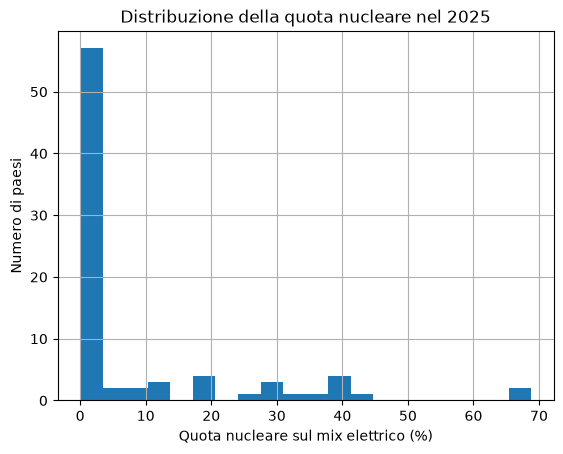

In [19]:
df_ultimo_anno["nuclear_share_elec"].hist(bins=20)
plt.xlabel("Quota nucleare sul mix elettrico (%)")
plt.ylabel("Numero di paesi")
plt.title(f"Distribuzione della quota nucleare nel {2025}")
plt.show()

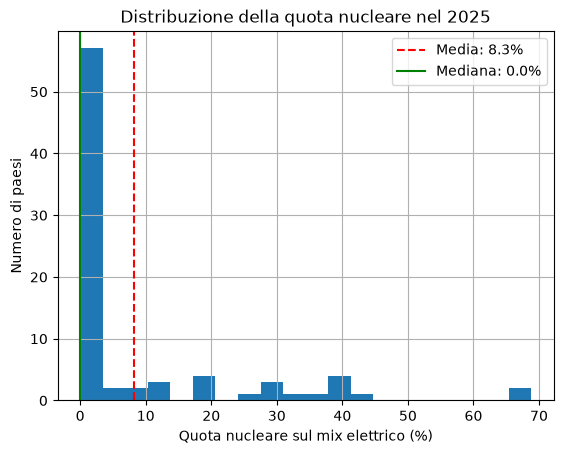

In [20]:
media = df_ultimo_anno["nuclear_share_elec"].mean()
mediana = df_ultimo_anno["nuclear_share_elec"].median()

df_ultimo_anno["nuclear_share_elec"].hist(bins=20)
plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.1f}%")
plt.axvline(mediana, color="green", linestyle="-", label=f"Mediana: {mediana:.1f}%")
plt.xlabel("Quota nucleare sul mix elettrico (%)")
plt.ylabel("Numero di paesi")
plt.title(f"Distribuzione della quota nucleare nel {2025}")
plt.legend()
plt.show()

## Commento grafico
Il grafico pone in relazione la quota di nucleare sul mix elettrico per numero di paesi. Si nota che la distribuzione è fortemente asimmetrica (mediana nulla) con una media di 8,3% di produzione nucleare nel mix elettrico.

## Andamento storico produzione nucleare

In [21]:
paesi_interesse = ["France", "United States", "Italy", "Germany", "China", "Japan"]

df_storico = df_nuclear[df_nuclear["country"].isin(paesi_interesse)]
df_storico["country"].unique()

<StringArray>
['China', 'France', 'Germany', 'Italy', 'Japan', 'United States']
Length: 6, dtype: str

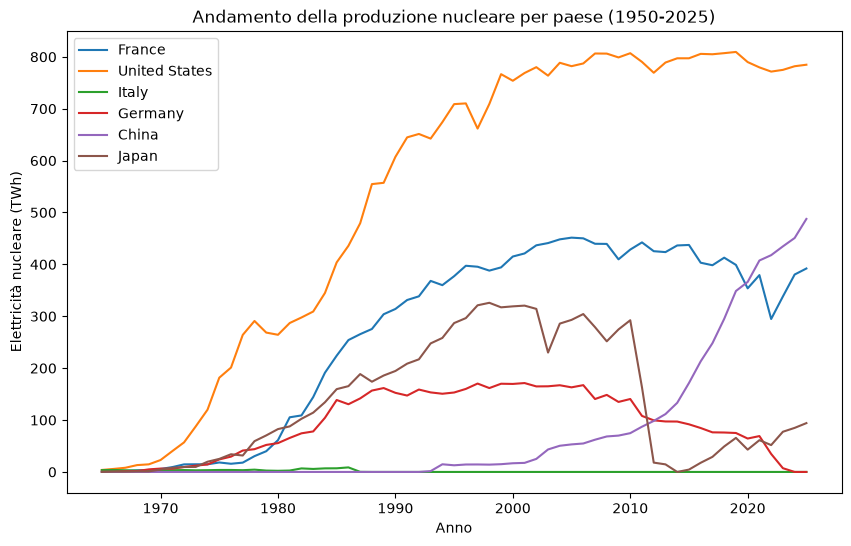

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

for paese in paesi_interesse:
    dati_paese = df_storico[df_storico["country"] == paese]
    ax.plot(dati_paese["year"], dati_paese["nuclear_electricity"], label=paese)

ax.set_xlabel("Anno")
ax.set_ylabel("Elettricità nucleare (TWh)")
ax.set_title("Andamento della produzione nucleare per paese (1950-2025)")
ax.legend()
plt.show()

## Commenti sul grafico
 Il grafico mostra la quota di elettricità da fonte nucleare prodotta, per paese, in un intervallo che va dal 1950 al 2025. Si è preso questo intervallo in quanto la produzione di energia elettrica è stata avviata intorno al 1950. Dal grafico si nota subito che si è avuta produzione nucleare, in Italia, dal 1970 circa al 1987 anno del referendum. Dopo il 1987 la produzione è nulla. Il Giappone ha avuto un progressivo aumento di produzione dal 1970 al 2011, anno del disastro di Fukushima che coincide con la diminuzione della produzione. Si nota una leggera risalita negli anni successivi. La Cina mostra un notevole aumento di produzione nucleare dalla seconda metà degli anni 90, riuscendo a superare la produzione netta della Francia. La Francia, è il paese che ha investito maggiormente sul nucleare sviluppando un sistema energetico basato principalmente sul nucleare. Si nota che l'andamento è pressocché sempre in salita con lievi cali e riprese dovute anche a manutenzione degli impianti. La Germania ha prodotto energia nucleare fino alla data di phase out, intorno al 2021. La maggiore produzione di energia da nucleare appartiene agli Stati Uniti, il cui andamento è pressocché sempre in salita. 

## Analisi: produzione nucleare e PIL pro capite

In [23]:
colonne_corr = ["country", "iso_code", "year", "nuclear_share_elec", "gdp", "population"]
df_corr = df[colonne_corr]
df_corr.head()

,country,iso_code,year,nuclear_share_elec,gdp,population
0,ASEAN (Ember),NaN,2000,0.0,NaN,NaN
1,ASEAN (Ember),NaN,2001,0.0,NaN,NaN
2,ASEAN (Ember),NaN,2002,0.0,NaN,NaN
3,ASEAN (Ember),NaN,2003,0.0,NaN,NaN
4,ASEAN (Ember),NaN,2004,0.0,NaN,NaN


In [24]:
# Tolgo gli aggregati regionali (senza iso_code)
df_corr = df_corr[df_corr["iso_code"].notna()]

# Tolgo le righe dove mancano i dati che mi servono per la correlazione
df_corr = df_corr.dropna(subset=["nuclear_share_elec", "gdp", "population"])

df_corr.shape

(4918, 6)

In [25]:
df_corr["gdp_pro_capite"] = df_corr["gdp"] / df_corr["population"]
df_corr.head()

,country,iso_code,year,nuclear_share_elec,gdp,population,gdp_pro_capite
126,Afghanistan,AFG,2000,0.0,1.128379e+10,20130334.0,560.536857
127,Afghanistan,AFG,2001,0.0,1.102127e+10,20284303.0,543.339987
128,Afghanistan,AFG,2002,0.0,1.880487e+10,21378123.0,879.631552
129,Afghanistan,AFG,2003,0.0,2.107434e+10,22733053.0,927.035336
130,Afghanistan,AFG,2004,0.0,2.233257e+10,23560656.0,947.875583


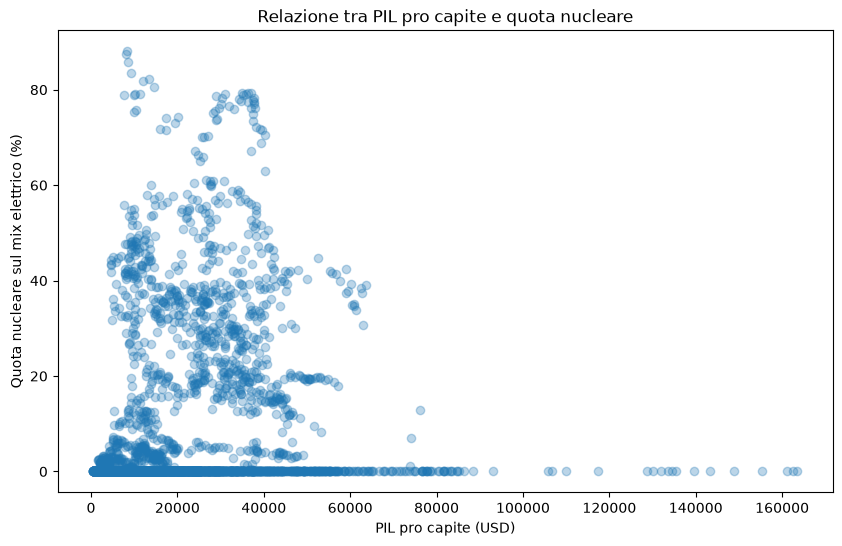

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_corr["gdp_pro_capite"], df_corr["nuclear_share_elec"], alpha=0.3)

ax.set_xlabel("PIL pro capite (USD)")
ax.set_ylabel("Quota nucleare sul mix elettrico (%)")
ax.set_title("Relazione tra PIL pro capite e quota nucleare")
plt.show()

In [27]:
df_corr["gdp_pro_capite"].corr(df_corr["nuclear_share_elec"]) # calcolo il coefficiente di correlazione di Pearson

np.float64(0.23041703196668376)

## Commento risultati

Dal grafico a dispersione si nota già una lieve correlazione tra PIL pro capite e produzione di energia nucleare. Infatti, oltre certi valori di PIL pro capite, 60-70k USD, la quota di nucleare è bassa. La fascia in cui si concentra di più la produzione di energia da fonte nucleare è quella che va da 0 a 44000 circa. Il PIL pro capite, quindi ci restituisce poche informazioni relative alla produzione di energia da fonte nucleare. Calcolando il coefficiente di correlazione di Pearson si trova riscontro su quanto osservato. La correlazione c'è ma è molto debole. Pertanto, l'informazione relativa allo status economico medio della popolazione non dà informazioni certe sulla scelta energetica da parte di un paese che resta pressoché politica, sociale e storica.

## Analisi: produzione nucleare e PIL totale

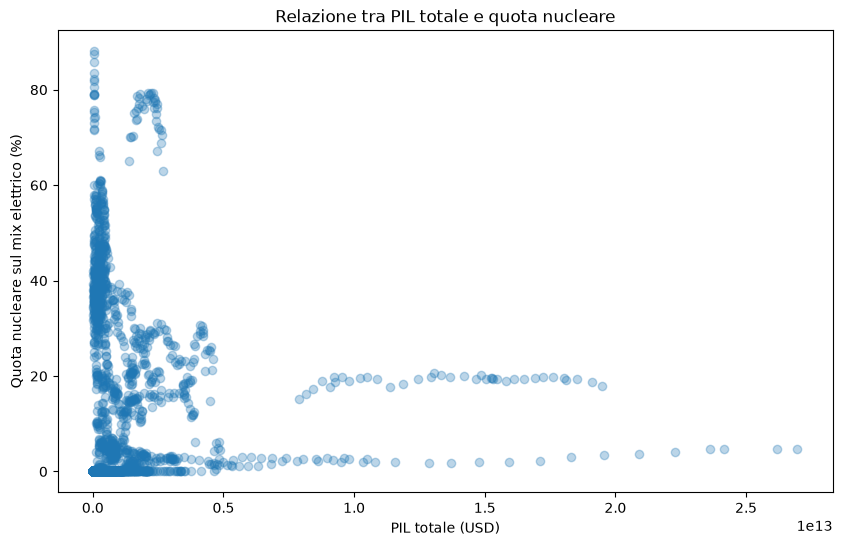

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_corr["gdp"], df_corr["nuclear_share_elec"], alpha=0.3)

ax.set_xlabel("PIL totale (USD)")
ax.set_ylabel("Quota nucleare sul mix elettrico (%)")
ax.set_title("Relazione tra PIL totale e quota nucleare")
plt.show()

In [29]:
df_corr["gdp"].corr(df_corr["nuclear_share_elec"])

np.float64(0.13266294484249871)

## Commento risultati
La relazione tra quota nucleare e PIL totale ha una correlazione meno forte rispetto a quella pro capite, con un coefficiente r pari a 0.13 a fronte del 0.23 pro capite. La distribuzione è fortemente asimmetrica, si nota una concentrazione di produzione in corrispondenza di PIL basso. Si evidenziano anche dei punti fuori dal trend, corrispondenti ad economie più avanzate (Es. Usa) con quota nucleare modesta. Altri paesi, come Cina ed India, nonostante il PIL sia estremamente elevato, la quota nucleare è bassa. Il grafico conferma che l'informazione economica dà poche informazioni rispetto alle scelte in campo energetico da parte di una nazione. 

## Conclusioni

L'analisi mostra che la produzione di energia nucleare nel mondo è distribuita in modo fortemente asimmetrico: la maggior parte dei paesi non ha nucleare (mediana della quota = 0%), mentre pochi paesi, su tutti la Francia (~69%), sono outlier molto distanti dalla media (~8,3%).

Né il PIL pro capite (r = 0.23) né il PIL totale (r = 0.13) mostrano una correlazione significativa con la quota di nucleare nel mix elettrico. Questo suggerisce che la decisione di un paese di investire in energia nucleare non dipende principalmente dalla sua ricchezza economica, ma da fattori storici, politici e di sicurezza energetica, coerente con l'evoluzione osservata nel grafico storico (uscita italiana post-referendum, crollo giapponese post-Fukushima, crescita cinese, phase-out tedesco).